## Lec 3. 卷积神经网络 CNN (Convolution Neural Network)

- 卷积神经网络 (互相关运算)

In [65]:
def corr2d(x, kernel):
    """ 互相关运算函数 """
    h_x, w_x = x.shape
    h_k, w_k = kernel.shape
    y = torch.zeros((h_x-h_k+1, w_x-w_k+1))
    for i in range(y.shape[0]):
        for j in range(y.shape[1]):
            y[i, j] = (x[i: i + h_k, j: j + w_k] * kernel).sum()
    return y

In [77]:
x = torch.tensor([[0, 1, 2], [3, 4, 5], [6, 7, 8]])
kernel = torch.tensor([[-1, 0], [0, -1]])
kernel

tensor([[-1,  0],
        [ 0, -1]])

In [78]:
corr2d(x, kernel)

tensor([[ -4.,  -6.],
        [-10., -12.]])

In [87]:
class Conv2d(nn.Module):
    """ 二维卷积神经网络层 """
    def __init__(self, kernel_size):
        super().__init__()
        self.weight = nn.Parameter(torch.rand(kernel_size))
        self.bias = nn.Parameter(torch.zeros(1))
        
    def forward(self, x):
        """ 前向传播方法 """
        return corr2d(x, self.weight) + self.bias

In [88]:
model = Conv2d(kernel_size=(2, 2))
model

Conv2d()

In [94]:
output = model(x)
output

tensor([[ 4.2098,  6.2108],
        [10.2129, 12.2140]], grad_fn=<AddBackward0>)

In [104]:
model = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=0)
model

Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))

In [113]:
# x: [B, C, H, W]
# img: [C, H, W] -> unsqueeze(0)
output = model(img.unsqueeze(0))
output.shape  # output: [B, C, H, W]

torch.Size([1, 16, 26, 26])

### 3.1 Fasion-MNIST 图像识别任务 (线性神经网络)

In [6]:
import torch
import torchvision
from torch.utils import data
from torchvision import transforms

trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(root="../data", train=True, transform=trans, download = True)
mnist_test = torchvision.datasets.FashionMNIST(root="../data", train=False, transform=trans, download = True)

len(mnist_train), len(mnist_test)

100%|██████████| 26.4M/26.4M [00:16<00:00, 1.63MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 127kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 1.84MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]


(60000, 10000)

In [14]:
import torch.nn as nn

class LinearClassifier(nn.Module):
    """ 基于线性神经网络的分类模型 """
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(784, 256), 
                                nn.ReLU(), 
                                nn.Linear(256, 10))
        
    def forward(self, x):
        """ 前向传播方法 """
        return self.fc(x)
    
model = LinearClassifier()

In [16]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(mnist_train, batch_size=256, shuffle=True)
test_dataloader = DataLoader(mnist_test, batch_size=256, shuffle=False)

len(train_dataloader)

235

In [18]:
def train_model(model, train_dataloader, loss_func, optimizer):
    """ 模型训练函数 """
    model.train()
    total_loss = 0.
    for x, y in train_dataloader:
        # x: [batch_size, 1, 28, 28]
        # y: [batch_size]
        y_hat = model(x.view(x.shape[0], -1).to(device))
        loss = loss_func(y_hat, y.to(device))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(train_dataloader)


def test_model(model, test_dataloader, loss_func):
    """ 模型测试函数 """
    model.eval()
    total_loss = 0.
    for x, y in test_dataloader:
        # x: [batch_size, 1, 28, 28]
        # y: [batch_size]
        y_hat = model(x.view(x.shape[0], -1).to(device))
        loss = loss_func(y_hat, y.to(device))
        
        total_loss += loss.item()
    return total_loss / len(train_dataloader)

In [20]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cpu')

In [22]:
model = LinearClassifier().to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [24]:
n_epoch = 50

train_loss_list = []
test_loss_list = []
for i in range(n_epoch):
    train_loss = train_model(model, train_dataloader, loss_func, optimizer)
    test_loss = test_model(model, train_dataloader, loss_func)
    
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)
    print(train_loss)

0.6198550414531789
0.4250946944064282
0.3845850125272223
0.35719656348228457
0.3357953209192195
0.31366463360634256
0.3015582623633933
0.2902935297565257
0.28051288584445383
0.26888042872256424
0.26202024804784896
0.2538242585481481
0.24531062169277923
0.23794556463018376
0.23174857598669985
0.22711411530667164
0.21884110100725865
0.2113505040711545
0.20825607354970688
0.20457076557139134
0.19634951026515757
0.19303455019884921
0.18764912482905896
0.18373556441449104
0.17515567195542314
0.17488101568627865
0.1709208570262219
0.16902566276332165
0.16268592448310648
0.15740959660169926
0.154789810738665
0.14823564658773705
0.14637300229453026
0.14078959277335634
0.14261496647241267
0.13561148890789518
0.13353143895560124
0.12854596832965282
0.12642564510411405
0.12307563129257648
0.12181254477894053
0.12035954521691546
0.11523210271558863
0.11192853090927955
0.11182893337087428
0.11086127418786922
0.10525205913693347
0.10318696563865276
0.10068938984198773
0.09665454767168837


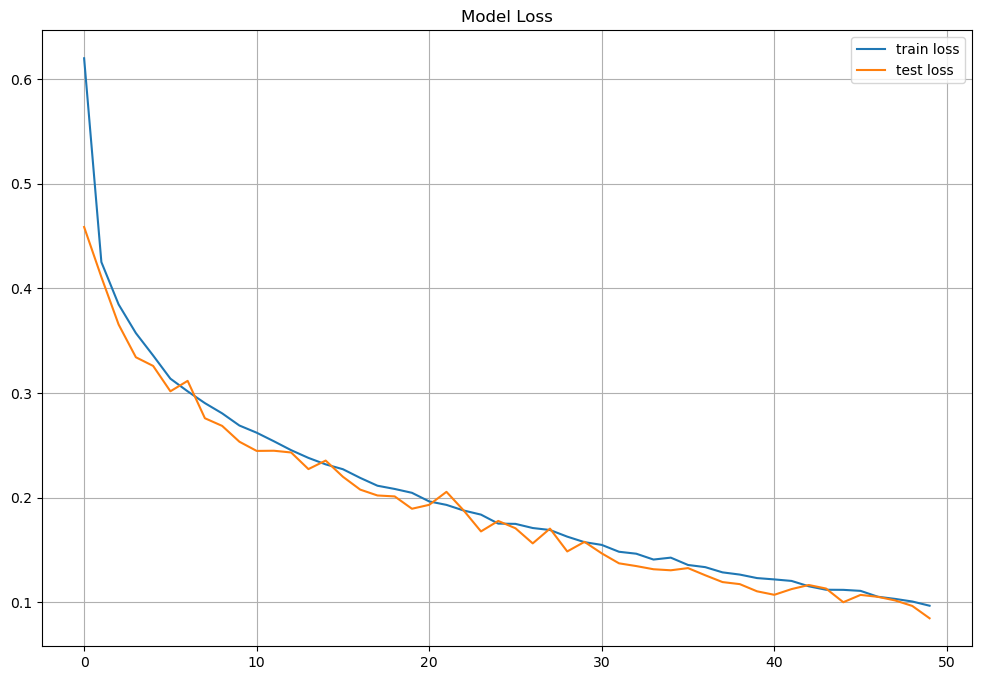

In [26]:
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

plt.figure(figsize=(12, 8))
plt.plot(train_loss_list, label="train loss")
plt.plot(test_loss_list, label="test loss")
plt.title("Model Loss")
plt.grid()
plt.legend()
plt.show()

### 3.2 Fasion-MNIST 图像识别任务 (线性神经网络)

In [116]:
class LeNet(nn.Module):
    """ 二维卷积神经网络分类模型 """
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(1, 6, kernel_size=5, padding=2), 
                                  nn.Sigmoid(), 
                                  nn.AvgPool2d(kernel_size=2, stride=2), 
                                 
                                  nn.Conv2d(6, 16, kernel_size=5), 
                                  nn.Sigmoid(), 
                                  nn.AvgPool2d(kernel_size=2, stride=2))
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(nn.Linear(16*5*5, 120), 
                                nn.Sigmoid(), 
                                
                                nn.Linear(120, 84), 
                                nn.Sigmoid(), 
                                
                                nn.Linear(84, 10))
        
    def forward(self, x):
        """ 前向传播方法 """
        feat_map = self.conv(x)
        output = self.flatten(feat_map)
        return self.fc(output)

In [119]:
model = LeNet()
model

LeNet(
  (conv): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Sigmoid()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Sigmoid()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=120, out_features=84, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=84, out_features=10, bias=True)
  )
)

In [123]:
output = model(img.unsqueeze(0))
output

tensor([[-0.1824,  0.4441,  0.4490,  0.0103,  0.6376,  0.0482, -0.6147,  0.4961,
         -0.0258, -0.2590]], grad_fn=<AddmmBackward>)

In [ ]:
1. Load Dataset
2. Model
(model, loss_func, optimizer, device)
3. Train Model
4. Test Model
5. Plot Loss (epoch>=30)